# Notebook 01 - Data Quality Assessment

**Project:** Provider Aberrant Billing Pattern Detection (P3)  
**Data source:** CMS DE-SynPUF (Data Entrepreneurs' Synthetic Public Use File)  
**Technology:** Python 3.11+ / DuckDB / pandas / seaborn / matplotlib

---

## Purpose

This notebook performs a comprehensive data quality assessment **before any analytical work begins**. Every downstream decision - column exclusions, minimum volume thresholds, distributional assumptions for z-scores, peer group definitions - is grounded in the findings documented here.

The assessment covers five dimensions:
1. **Completeness** - % of non-null values per column, per table
2. **Distributions** - Shape of payment amounts, provider volumes, beneficiary demographics
3. **Referential integrity** - Orphaned keys between tables
4. **Temporal consistency** - Date logic violations
5. **Quality contract** - Formal acceptance/rejection of columns for downstream use

**A note on technology choices:** This project deliberately implements the same analytical pipeline across Snowflake (SQL), SAS, and Python/DuckDB. In a production setting, a single technology stack would be selected based on organizational infrastructure, licensing, and team expertise. The multi-stack approach here demonstrates proficiency across the technologies most commonly found in US healthcare FWA operations - from legacy SAS environments at established payers to modern cloud-native platforms at AI-driven vendors.

In [17]:
import sys
import warnings
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

pd.set_option('display.float_format', lambda x: f'{x:.8f}')

from pathlib import Path
_cwd = Path.cwd()
if (_cwd / 'src').is_dir():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / 'src').is_dir():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = Path('/home/aosousa/Documents/PORTFOLIO/Fraud-Waste-Abuse-FWA/'
                        'CMS DE-SynPUF MEDICARE/provider-aberrant-billing-detection')
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    DESYNPUF_PATHS, EXPECTED_ROWS, FIGURES_DIR, OUTPUT_DIR,
    CARRIER_LINE_GROUPS, CHRONIC_CONDITION_COLS,
    MIN_CLAIMS, MIN_PEER_GROUP_SIZE, DATA_SOURCE_CITATION,
)
from src.visual_identity import *
from src.data_loader import get_connection, create_carrier_lean, create_views
from src.quality import (
    compute_completeness, print_completeness_tiers,
    check_referential_integrity, check_temporal_consistency,
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Visual identity loaded. Serif: {SERIF} | Sans: {SANS}")
print(f"Figures output:  /provider-aberrant-billing-detection/outputs/figures")
print(f"Data source:     /data/desynpuf_csvs/carrier")

Visual identity loaded. Serif: Liberation Serif | Sans: Liberation Sans
Figures output:  /provider-aberrant-billing-detection/outputs/figures
Data source:     /data/desynpuf_csvs/carrier


## 1. Data loading

**Performance strategy:** Carrier claims (94M rows × 142 columns across 40 CSV files) are too large to scan repeatedly. We create a **materialized lean table** with only the ~72 columns needed for profiling, then use **views** for the smaller tables. This single materialization pass takes a few minutes but eliminates the need to re-read 48GB of CSV files for every downstream query.

In [2]:
con = get_connection(memory_limit='6GB', threads=4)

print("Setting up tables and views...\n")

# Beneficiary, inpatient, outpatient, PDE - lazy views
print("  Creating views (beneficiary, inpatient, outpatient, pde)...")
view_counts = create_views(con)
for name, count in view_counts.items():
    print(f"    {name:15s} : {count:>12,} rows (view)")

# Carrier - materialized lean table (one-time cost)
print("\n  Materializing carrier_lean (this takes a few minutes)...")
carrier_count = create_carrier_lean(con)
carrier_cols = len(con.execute("SELECT * FROM carrier_lean LIMIT 0").description)
print(f"    carrier_lean    : {carrier_count:>12,} rows × {carrier_cols} cols (materialized)")

print("\n  Done. All subsequent queries hit in-memory data.")

Setting up tables and views...

  Creating views (beneficiary, inpatient, outpatient, pde)...
    beneficiary     :    6,873,274 rows (view)
    inpatient       :    1,332,822 rows (view)
    outpatient      :   15,826,987 rows (view)
    pde             :  111,085,969 rows (view)

  Materializing carrier_lean (this takes a few minutes)...
    carrier_lean    :   94,863,452 rows × 68 cols (materialized)

  Done. All subsequent queries hit in-memory data.


## 2. Table overview

Cross-validation: row counts must match the Snowflake staging load exactly.

In [3]:
tables_to_check = {
    'beneficiary':  'beneficiary',
    'carrier':      'carrier_lean',
    'inpatient':    'inpatient',
    'outpatient':   'outpatient',
    'pde':          'pde',
}

print("Table overview (cross-validated against Snowflake):")
print("=" * 72)
for source_name, table_name in tables_to_check.items():
    actual = con.execute(f"SELECT COUNT(*) FROM {table_name}").fetchone()[0]
    expected = EXPECTED_ROWS.get(source_name, 0)
    col_count = len(con.execute(f"SELECT * FROM {table_name} LIMIT 0").description)
    match = '✓' if actual == expected else f"Δ {actual - expected:+,}"
    print(f"  {source_name:15s}  {col_count:3d} cols  {actual:>14,} rows  {match}")
print("=" * 72)

Table overview (cross-validated against Snowflake):
  beneficiary       34 cols       6,873,274 rows  ✓
  carrier           68 cols      94,863,452 rows  ✓
  inpatient         83 cols       1,332,822 rows  ✓
  outpatient        78 cols      15,826,987 rows  ✓
  pde               10 cols     111,085,969 rows  ✓


## 3. Completeness analysis

Single-pass computation: one SQL statement counts all columns at once instead of running separate queries per column.

**Scope note:** For data quality profiling, we examine the materialized `carrier_lean` table (72 columns covering line items 1–13). The full 142-column carrier file and the unpivoted line-level detail (all 13 positions in `FACT_CARRIER_CLAIM_LINES`) are used in the Snowflake dimensional model and in Notebooks 03–05.

In [4]:
print("Computing completeness for carrier_lean (single pass)...\n")
df_comp_carrier = compute_completeness(con, 'carrier_lean')
print_completeness_tiers(df_comp_carrier)

Computing completeness for carrier_lean (single pass)...

Completeness summary (68 columns):

  100% complete: 34 columns
    DESYNPUF_ID                              100.00%
    CLM_ID                                   100.00%
    CLM_FROM_DT                              100.00%
    CLM_THRU_DT                              100.00%
    ICD9_DGNS_CD_1                           100.00%
    LINE_NCH_PMT_AMT_1                       100.00%
    LINE_ALOWD_CHRG_AMT_1                    100.00%
    LINE_BENE_PTB_DDCTBL_AMT_1               100.00%
    LINE_COINSRNC_AMT_1                      100.00%
    LINE_PRCSG_IND_CD_1                      100.00%
    LINE_NCH_PMT_AMT_2                       100.00%
    LINE_ALOWD_CHRG_AMT_2                    100.00%
    LINE_NCH_PMT_AMT_3                       100.00%
    LINE_ALOWD_CHRG_AMT_3                    100.00%
    LINE_NCH_PMT_AMT_4                       100.00%
    ... and 19 more

  90-99%: 3 columns
    PRF_PHYSN_NPI_1                       

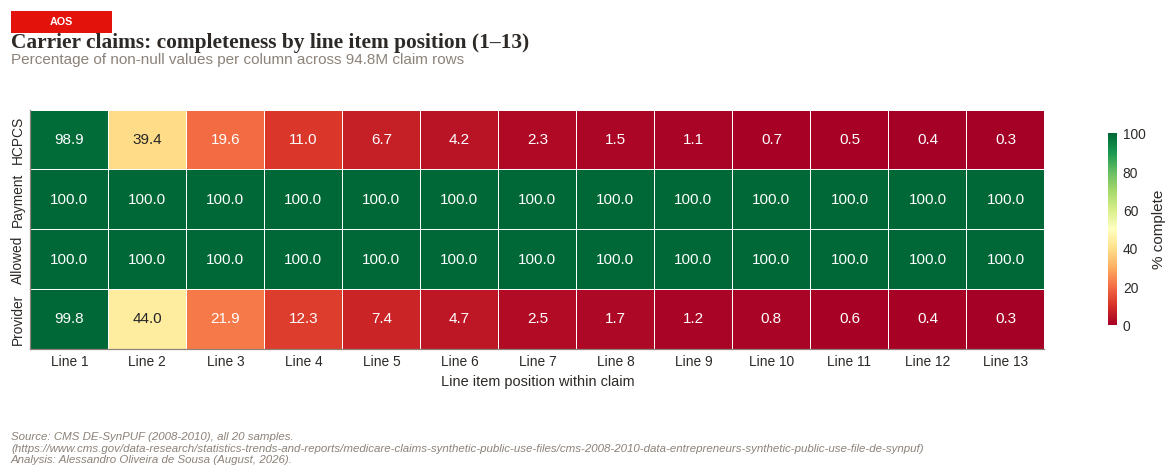

Key finding: completeness drops sharply after line 1–2.
Most claims have 1–3 line items; positions 4–13 are sparse.
The Snowflake unpivot filters on HCPCS_CD IS NOT NULL, which correctly
excludes empty line item slots.


In [6]:
# =============================================================================
# Completeness heatmap - carrier line-level columns (1–13)
# =============================================================================

heatmap_data = []
for group_name, cols in CARRIER_LINE_GROUPS.items():
    row = []
    for col in cols:
        match = df_comp_carrier[df_comp_carrier['column'] == col]
        row.append(match.iloc[0]['pct_complete'] if len(match) > 0 else 0)
    heatmap_data.append(row)

df_heatmap = pd.DataFrame(
    heatmap_data,
    index=list(CARRIER_LINE_GROUPS.keys()),
    columns=[f'Line {i}' for i in range(1, 14)]
)

fig, ax = plt.subplots(figsize=(12, 3.5))
sns.heatmap(
    df_heatmap, annot=True, fmt='.1f',
    cmap='RdYlGn', vmin=0, vmax=100,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': '% complete', 'shrink': 0.8},
    ax=ax
)
adjust_axis(ax, xlabel='Line item position within claim')
ax.set_ylabel('')
fig_title(fig,
          title= 'Carrier claims: completeness by line item position (1–13)',
          subtitle='Percentage of non-null values per column across 94.8M claim rows',
          top=0.86)
visual_identity(fig)
plt.savefig(FIGURES_DIR / 'completeness_heatmap_carrier.png')
plt.show()

print("Key finding: completeness drops sharply after line 1–2.")
print("Most claims have 1–3 line items; positions 4–13 are sparse.")
print("The Snowflake unpivot filters on HCPCS_CD IS NOT NULL, which correctly")
print("excludes empty line item slots.")

In [8]:
print("Computing completeness for beneficiary (single pass)...\n")
df_comp_bene = compute_completeness(con, 'beneficiary')

print(f"Beneficiary completeness ({len(df_comp_bene)} columns):")
print("=" * 60)
for _, r in df_comp_bene.iterrows():
    flag = ' ← DEATH DATE (expected sparse)' if r['column'] == 'BENE_DEATH_DT' else ''
    print(f"  {r['column']:35s} {r['pct_complete']:7.2f}%{flag}")

Computing completeness for beneficiary (single pass)...

Beneficiary completeness (32 columns):
  DESYNPUF_ID                          100.00%
  BENE_BIRTH_DT                        100.00%
  BENE_DEATH_DT                          1.57% ← DEATH DATE (expected sparse)
  BENE_SEX_IDENT_CD                    100.00%
  BENE_RACE_CD                         100.00%
  BENE_ESRD_IND                        100.00%
  SP_STATE_CODE                        100.00%
  BENE_COUNTY_CD                       100.00%
  BENE_HI_CVRAGE_TOT_MONS              100.00%
  BENE_SMI_CVRAGE_TOT_MONS             100.00%
  BENE_HMO_CVRAGE_TOT_MONS             100.00%
  PLAN_CVRG_MOS_NUM                    100.00%
  SP_ALZHDMTA                          100.00%
  SP_CHF                               100.00%
  SP_CHRNKIDN                          100.00%
  SP_CNCR                              100.00%
  SP_COPD                              100.00%
  SP_DEPRESSN                          100.00%
  SP_DIABETES              

## 4. Distribution analysis

### 4.1 Payment amount distribution

Distribution statistics are computed **in SQL** - no need to pull 94M rows into pandas. Only pre-binned histogram data is fetched for plotting.

In [9]:
# =============================================================================
# Payment amount statistics - single SQL query
# =============================================================================

df_stats = con.execute("""
    SELECT
        COUNT(*)                                     AS n,
        AVG(CAST(LINE_NCH_PMT_AMT_1 AS DOUBLE))     AS mean_val,
        MEDIAN(CAST(LINE_NCH_PMT_AMT_1 AS DOUBLE))  AS median_val,
        STDDEV(CAST(LINE_NCH_PMT_AMT_1 AS DOUBLE))  AS sd_val,
        MIN(CAST(LINE_NCH_PMT_AMT_1 AS DOUBLE))     AS min_val,
        MAX(CAST(LINE_NCH_PMT_AMT_1 AS DOUBLE))     AS max_val,
        PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY CAST(LINE_NCH_PMT_AMT_1 AS DOUBLE)) AS p25,
        PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY CAST(LINE_NCH_PMT_AMT_1 AS DOUBLE)) AS p75,
        PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY CAST(LINE_NCH_PMT_AMT_1 AS DOUBLE)) AS p95,
        PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY CAST(LINE_NCH_PMT_AMT_1 AS DOUBLE)) AS p99
    FROM carrier_lean
    WHERE LINE_NCH_PMT_AMT_1 IS NOT NULL
      AND CAST(LINE_NCH_PMT_AMT_1 AS DOUBLE) > 0
""").fetchdf()

print("Payment amount statistics (LINE_NCH_PMT_AMT_1, > $0):")
print("=" * 50)
for col in df_stats.columns:
    val = df_stats[col].iloc[0]
    if col == 'n':
        print(f"  {col:12s} : {int(val):>14,}")
    else:
        print(f"  {col:12s} : ${val:>14,.2f}")

# Skewness - computed in SQL
skew_result = con.execute("""
    SELECT
        (SUM(POWER(val - mean_val, 3)) / COUNT(*)) / POWER(STDDEV(val), 3) AS skewness,
        (SUM(POWER(LN(val) - mean_log, 3)) / COUNT(*)) / POWER(STDDEV(LN(val)), 3) AS log_skewness
    FROM (
        SELECT
            CAST(LINE_NCH_PMT_AMT_1 AS DOUBLE) AS val,
            AVG(CAST(LINE_NCH_PMT_AMT_1 AS DOUBLE)) OVER () AS mean_val,
            AVG(LN(CAST(LINE_NCH_PMT_AMT_1 AS DOUBLE))) OVER () AS mean_log
        FROM carrier_lean
        WHERE LINE_NCH_PMT_AMT_1 IS NOT NULL
          AND CAST(LINE_NCH_PMT_AMT_1 AS DOUBLE) > 0
    )
""").fetchdf()

skew = skew_result['skewness'].iloc[0]
log_skew = skew_result['log_skewness'].iloc[0]

print(f"\nSkewness (raw):           {skew:.4f}  (> 2 = strong right skew)")
print(f"Skewness (log-transform): {log_skew:.4f}  (closer to 0 = more symmetric)")

print("\nNote: DE-SynPUF payment amounts are drawn from a discrete synthetic")
print("distribution (round values). This limits distributional granularity")
print("but does not affect the methodological demonstration.")

Payment amount statistics (LINE_NCH_PMT_AMT_1, > $0):
  n            :     78,913,801
  mean_val     : $         69.47
  median_val   : $         50.00
  sd_val       : $         82.59
  min_val      : $         10.00
  max_val      : $        550.00
  p25          : $         20.00
  p75          : $         80.00
  p95          : $        200.00
  p99          : $        550.00

Skewness (raw):           3.4401  (> 2 = strong right skew)
Skewness (log-transform): 0.0705  (closer to 0 = more symmetric)

Note: DE-SynPUF payment amounts are drawn from a discrete synthetic
distribution (round values). This limits distributional granularity
but does not affect the methodological demonstration.


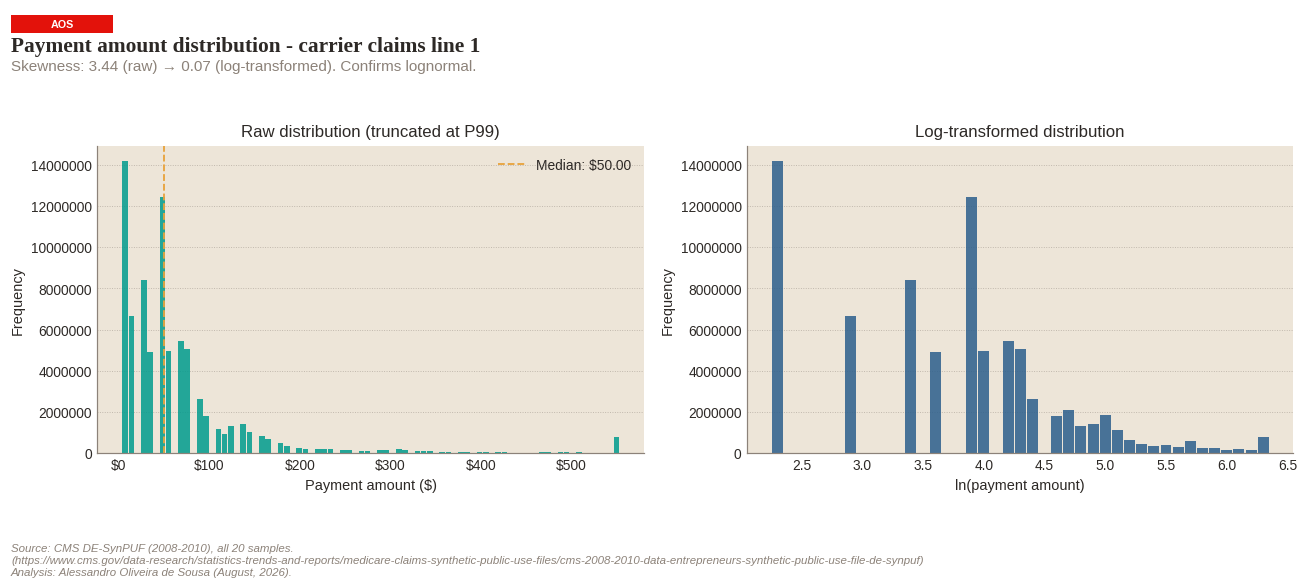

Conclusion: Payment amounts are strongly right-skewed (lognormal).
Z-scores should be computed on log-transformed values.


In [27]:
# =============================================================================
# Histogram
# =============================================================================

p99_val = df_stats['p99'].iloc[0]
median_val = df_stats['median_val'].iloc[0]
bin_width = p99_val / 80

df_hist_raw = con.execute(f"""
    SELECT
        FLOOR(CAST(LINE_NCH_PMT_AMT_1 AS DOUBLE) / {bin_width}) * {bin_width} AS bin_start,
        COUNT(*) AS freq
    FROM carrier_lean
    WHERE LINE_NCH_PMT_AMT_1 IS NOT NULL
      AND CAST(LINE_NCH_PMT_AMT_1 AS DOUBLE) > 0
      AND CAST(LINE_NCH_PMT_AMT_1 AS DOUBLE) <= {p99_val}
    GROUP BY bin_start
    ORDER BY bin_start
""").fetchdf()

df_hist_log = con.execute("""
    SELECT
        FLOOR(LN(CAST(LINE_NCH_PMT_AMT_1 AS DOUBLE)) / 0.1) * 0.1 AS bin_start,
        COUNT(*) AS freq
    FROM carrier_lean
    WHERE LINE_NCH_PMT_AMT_1 IS NOT NULL
      AND CAST(LINE_NCH_PMT_AMT_1 AS DOUBLE) > 0
    GROUP BY bin_start
    ORDER BY bin_start
""").fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.bar(df_hist_raw['bin_start'], df_hist_raw['freq'],
       width=bin_width * 0.9, color=NATURE_TEAL, alpha=0.85)
ax.axvline(median_val, color=AMBER, linestyle='--', linewidth=1.2,
           label=f"Median: ${median_val:,.2f}")
adjust_axis(ax, xlabel='Payment amount ($)', ylabel='Frequency')
ax.set_title('Raw distribution (truncated at P99)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_usd))
ax.legend(fontsize=9)

ax = axes[1]
ax.bar(df_hist_log['bin_start'], df_hist_log['freq'],
       width=0.09, color=DEEP_BLUE, alpha=0.85)

adjust_axis(ax, xlabel='ln(payment amount)', ylabel='Frequency')
ax.set_title('Log-transformed distribution', fontsize=11)

fig_title(fig,
          title='Payment amount distribution - carrier claims line 1',
          subtitle=f'Skewness: {skew:.2f} (raw) → {log_skew:.2f} (log-transformed). Confirms lognormal.',
          top=0.86)
visual_identity(fig)
plt.savefig(FIGURES_DIR / 'payment_distribution_raw_vs_log.png')
plt.show()

print("Conclusion: Payment amounts are strongly right-skewed (lognormal).")
print("Z-scores should be computed on log-transformed values.")

### 4.2 Provider volume distribution

Determines the minimum claim volume threshold for including a provider in peer comparison. Providers with very few claims produce unstable metrics.

In [28]:
df_prov_vol = con.execute(f"""
    SELECT
        PRF_PHYSN_NPI_1 AS provider_npi,
        COUNT(*) AS claim_count,
        COUNT(DISTINCT DESYNPUF_ID) AS distinct_beneficiaries,
        SUM(CAST(LINE_NCH_PMT_AMT_1 AS DOUBLE)) AS total_paid
    FROM carrier_lean
    WHERE PRF_PHYSN_NPI_1 IS NOT NULL
      AND PRF_PHYSN_NPI_1 != ''
    GROUP BY PRF_PHYSN_NPI_1
""").fetchdf()

total_provs = len(df_prov_vol)
excluded = (df_prov_vol['claim_count'] < MIN_CLAIMS).sum()

print(f"Distinct providers (line 1 NPI): {total_provs:,}")
print(f"\nClaim count per provider:")
print(df_prov_vol['claim_count'].describe().to_string())

vol_tiers = [
    (f'<{MIN_CLAIMS} claims', (df_prov_vol['claim_count'] < MIN_CLAIMS).sum()),
    (f'{MIN_CLAIMS}-50 claims', ((df_prov_vol['claim_count'] >= MIN_CLAIMS) & (df_prov_vol['claim_count'] < 51)).sum()),
    ('50-99 claims',  ((df_prov_vol['claim_count'] >= 50) & (df_prov_vol['claim_count'] < 100)).sum()),
    ('100+ claims',   (df_prov_vol['claim_count'] >= 100).sum()),
]

print(f"\nProvider volume tiers:")
print("=" * 50)
for tier_name, count in vol_tiers:
    print(f"  {tier_name:20s}  {count:>8,}  ({count/total_provs*100:5.1f}%)")

Distinct providers (line 1 NPI): 893,206

Claim count per provider:
count   893206.00000000
mean       106.00201073
std       1568.86498968
min          1.00000000
25%         10.00000000
50%         34.00000000
75%        100.00000000
max     586903.00000000

Provider volume tiers:
  <30 claims             414,832  ( 46.4%)
  30-50 claims           112,881  ( 12.6%)
  50-99 claims           144,810  ( 16.2%)
  100+ claims            224,960  ( 25.2%)


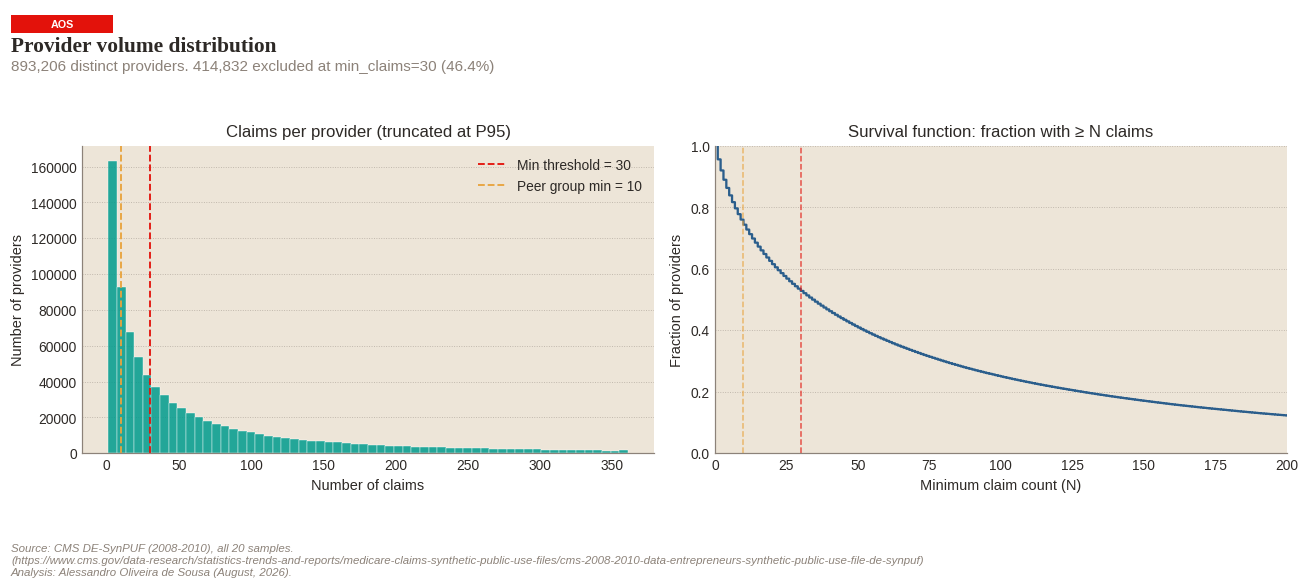

Providers excluded at min_claims=30: 414,832 (46.4%)
Providers retained: 478,374


In [30]:
# =============================================================================
# Visual: provider volume distribution
# =============================================================================

p95 = df_prov_vol['claim_count'].quantile(0.95)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.hist(df_prov_vol['claim_count'][df_prov_vol['claim_count'] <= p95],
        bins=60, color=NATURE_TEAL, edgecolor='white', linewidth=0.3, alpha=0.85)
ax.axvline(MIN_CLAIMS, color=ECON_RED, linestyle='--', linewidth=1.2,
           label=f'Min threshold = {MIN_CLAIMS}')
ax.axvline(MIN_PEER_GROUP_SIZE, color=AMBER, linestyle='--', linewidth=1.2,
           label=f'Peer group min = {MIN_PEER_GROUP_SIZE}')
adjust_axis(ax, xlabel='Number of claims', ylabel='Number of providers')
ax.set_title('Claims per provider (truncated at P95)', fontsize=11)
ax.legend(fontsize=9)

ax = axes[1]
sorted_counts = np.sort(df_prov_vol['claim_count'].values)
cdf = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)
ax.plot(sorted_counts, 1 - cdf, color=DEEP_BLUE, linewidth=1.5)
ax.axvline(MIN_CLAIMS, color=ECON_RED, linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(MIN_PEER_GROUP_SIZE, color=AMBER, linestyle='--', linewidth=1, alpha=0.7)
adjust_axis(ax, xlabel='Minimum claim count (N)', ylabel='Fraction of providers')
ax.set_title('Survival function: fraction with ≥ N claims', fontsize=11)
ax.set_xlim(0, 200)
ax.set_ylim(0, 1)

fig_title(fig,
          title='Provider volume distribution',
          subtitle=f'{total_provs:,} distinct providers. {excluded:,} excluded at min_claims={MIN_CLAIMS} ({excluded/total_provs*100:.1f}%)',
          top=0.86)
visual_identity(fig)
plt.savefig(FIGURES_DIR / 'provider_volume_distribution.png')
plt.show()

print(f"Providers excluded at min_claims={MIN_CLAIMS}: {excluded:,} ({excluded/total_provs*100:.1f}%)")
print(f"Providers retained: {total_provs - excluded:,}")

### 4.3 Top providers by claim volume

A quick investigation of extreme-volume providers. In production, NPPES taxonomy would distinguish individual vs organizational (facility/lab) NPIs.

In [31]:
top5 = df_prov_vol.nlargest(5, 'claim_count')

render_table(
    top5,
    title='Top 5 providers by claim volume',
    fmt={
        'claim_count': '{:,.0f}',
        'distinct_beneficiaries': '{:,.0f}',
        'total_paid': '${:,.2f}',
    }
)

top_npi = top5.iloc[0]['provider_npi']
top_claims = int(top5.iloc[0]['claim_count'])
median_claims = int(df_prov_vol['claim_count'].median())

print(f"\nProvider {top_npi} has {top_claims:,} claims - {top_claims/median_claims:,.0f}× the median.")
print("Likely a lab or facility NPI rather than an individual physician.")
print("In production, NPPES taxonomy code would confirm this classification.")

provider_npi,claim_count,distinct_beneficiaries,total_paid
0888901330,"586,903","347,921","$33,963,010.00"
8207899456,"426,801","288,245","$24,632,500.00"
9979265126,"388,734","264,954","$22,485,500.00"
1973668724,"336,437","94,307","$19,319,320.00"
2052541087,"327,045","234,026","$18,904,860.00"



Provider 0888901330 has 586,903 claims - 17,262× the median.
Likely a lab or facility NPI rather than an individual physician.
In production, NPPES taxonomy code would confirm this classification.


## 5. Referential integrity

In [ ]:
print("Referential integrity checks:")
print("=" * 80)

# Carrier -> beneficiary
ri_carrier = check_referential_integrity(
    con, 'carrier_lean', 'beneficiary', 'DESYNPUF_ID', 'DESYNPUF_ID',
    description='Carrier beneficiaries not in beneficiary table'
)
print(f"  {ri_carrier['status']}  {ri_carrier['check']}")
print(f"         {ri_carrier['orphan_count']:,} of {ri_carrier['total']:,} ({ri_carrier['pct']:.4f}%)")

# Beneficiary -> carrier
ri_bene = check_referential_integrity(
    con, 'beneficiary', 'carrier_lean', 'DESYNPUF_ID', 'DESYNPUF_ID',
    description='Beneficiaries with no carrier claims'
)
print(f"\n  ℹ INFO  {ri_bene['check']}")
print(f"         {ri_bene['orphan_count']:,} of {ri_bene['total']:,} ({ri_bene['pct']:.2f}%)")
print(f"         (Expected - not all beneficiaries use Part B)")

Referential integrity checks:
  ✓ PASS  Carrier beneficiaries not in beneficiary table
         0 of 1,972,836 (0.0000%)

  ℹ INFO  Beneficiaries with no carrier claims
         354,020 of 2,326,856 (15.21%)
         (Expected - not all beneficiaries use Part B)


## 6. Temporal consistency

In [ ]:
temporal = check_temporal_consistency(con, 'carrier_lean')

print("Temporal consistency checks:")
print("=" * 70)
print(f"  Service dates outside 2008-2010:")
print(f"    {temporal['date_range_violations']:,} of {temporal['total_rows']:,} ({temporal['pct_range']:.4f}%)")
print(f"\n  Service end date before start date:")
print(f"    {temporal['end_before_start']:,} of {temporal['total_rows']:,} ({temporal['pct_end_before_start']:.4f}%)")

# Claims after death - requires join
claims_after_death = con.execute("""
    SELECT COUNT(DISTINCT c.DESYNPUF_ID) AS bene_count
    FROM carrier_lean c
    JOIN beneficiary b ON c.DESYNPUF_ID = b.DESYNPUF_ID
    WHERE b.BENE_DEATH_DT IS NOT NULL
      AND TRY_CAST(c.CLM_FROM_DT AS DATE) > TRY_CAST(CAST(b.BENE_DEATH_DT AS VARCHAR) AS DATE)
""").fetchone()[0]

print(f"\n  Beneficiaries with claims after death date:")
print(f"    {claims_after_death:,} distinct beneficiaries")
print(f"    (Note: DE-SynPUF synthetic dates may introduce this artifact)")

Temporal consistency checks:
  Service dates outside 2008-2010:
    0 of 94,863,452 (0.0000%)

  Service end date before start date:
    0 of 94,863,452 (0.0000%)

  Beneficiaries with claims after death date:
    0 distinct beneficiaries
    (Note: DE-SynPUF synthetic dates may introduce this artifact)


## 7. Beneficiary demographics profile

In [ ]:
cc_cols_sql = ', '.join(
    f"SUM(CASE WHEN {col} = 1 THEN 1 ELSE 0 END) AS {name.lower().replace('/', '_').replace(' ', '_')}"
    for col, name in CHRONIC_CONDITION_COLS.items()
)

df_demo = con.execute(f"""
    SELECT
        COUNT(*) AS total,
        SUM(CASE WHEN BENE_SEX_IDENT_CD = 1 THEN 1 ELSE 0 END) AS male,
        SUM(CASE WHEN BENE_SEX_IDENT_CD = 2 THEN 1 ELSE 0 END) AS female,
        {cc_cols_sql}
    FROM beneficiary
    WHERE _source_file LIKE '%2008%'
""").fetchdf()

total = int(df_demo['total'].iloc[0])

print(f"Beneficiary demographics (2008 cohort, n={total:,}):")
print("=" * 55)
print(f"\n  Sex:")
print(f"    Male:    {int(df_demo['male'].iloc[0]):>10,}  ({df_demo['male'].iloc[0]/total*100:.1f}%)")
print(f"    Female:  {int(df_demo['female'].iloc[0]):>10,}  ({df_demo['female'].iloc[0]/total*100:.1f}%)")

cc_data = {}
print(f"\n  Chronic condition prevalence:")
for col, label in CHRONIC_CONDITION_COLS.items():
    col_lower = label.lower().replace('/', '_').replace(' ', '_')
    count = int(df_demo[col_lower].iloc[0])
    pct = count / total * 100
    cc_data[label] = pct
    print(f"    {label:25s} {count:>10,}  ({pct:.1f}%)")

Beneficiary demographics (2008 cohort, n=2,326,856):

  Sex:
    Male:     1,033,995  (44.4%)
    Female:   1,292,861  (55.6%)

  Chronic condition prevalence:
    Alzheimer/Dementia           447,035  (19.2%)
    Heart failure                662,147  (28.5%)
    Chronic kidney               374,463  (16.1%)
    Cancer                       147,952  (6.4%)
    COPD                         315,166  (13.5%)
    Depression                   496,659  (21.3%)
    Diabetes                     883,236  (38.0%)
    Ischemic heart               977,092  (42.0%)
    Osteoporosis                 404,774  (17.4%)
    RA/OA                        357,513  (15.4%)
    Stroke/TIA                   104,733  (4.5%)


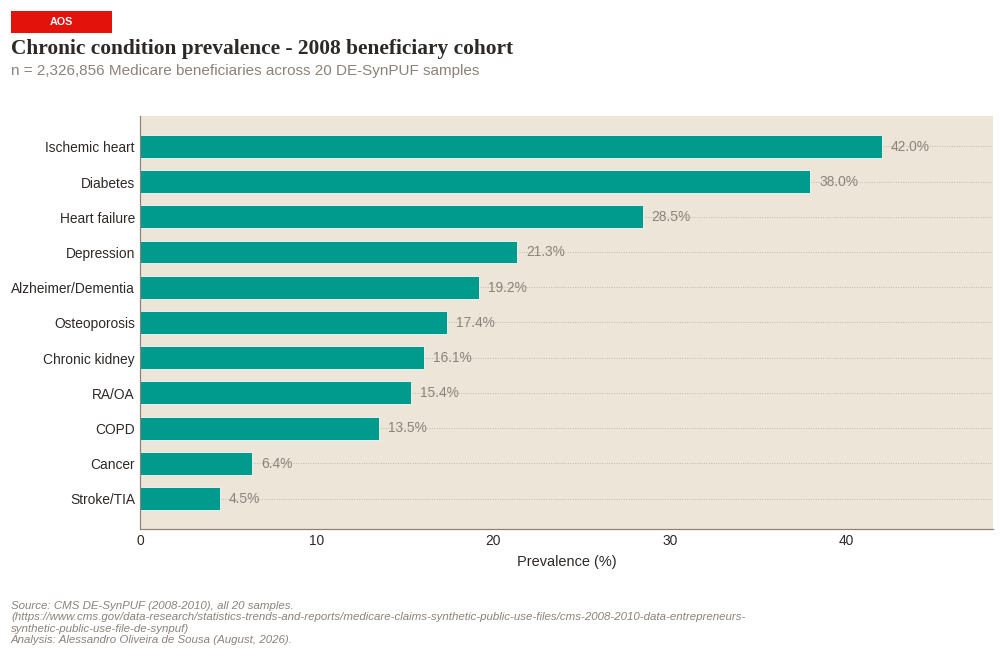

In [ ]:
cc_df = pd.DataFrame({'condition': list(cc_data.keys()), 'prevalence': list(cc_data.values())})
cc_df = cc_df.sort_values('prevalence', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cc_df['condition'], cc_df['prevalence'],
               color=NATURE_TEAL, edgecolor='white', linewidth=0.5, height=0.65)

for bar, val in zip(bars, cc_df['prevalence']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, color=WARM_GREY)

adjust_axis(ax, xlabel='Prevalence (%)')
ax.set_xlim(0, max(cc_data.values()) * 1.15)
fig_title(fig,
          ax,
          title='Chronic condition prevalence - 2008 beneficiary cohort',
          subtitle=f'n = {total:,} Medicare beneficiaries across 20 DE-SynPUF samples',
          top=0.86)
visual_identity(fig)
plt.savefig(FIGURES_DIR / 'chronic_condition_prevalence.png')
plt.show()

## 8. Quality contract

Based on the findings above, we formally document which columns and data subsets are accepted for downstream analysis.

In [ ]:
contract = [
    ('ACCEPT',             'Carrier LINE_NCH_PMT_AMT_1',
     'Core payment metric. High completeness. Use log-transform for z-scores.'),
    ('ACCEPT',             'Carrier LINE_ALOWD_CHRG_AMT_1',
     'Allowed charge amount. High completeness. Serves as billing benchmark.'),
    ('ACCEPT',             'Carrier PRF_PHYSN_NPI_1',
     'Provider identifier. Core grouping variable. Filter rows where NULL.'),
    ('ACCEPT',             'Carrier HCPCS_CD_1',
     'Procedure code. Used for specialty derivation and code diversity metrics.'),
    ('ACCEPT WITH CAUTION','Carrier line items 4–13',
     'Low completeness. Include in unpivot but do not compute per-position metrics.'),
    ('EXCLUDE',            f'Providers with <{MIN_CLAIMS} claims',
     f'Insufficient volume for stable metric computation. Threshold: MIN_CLAIMS={MIN_CLAIMS}.'),
    ('COLLAPSE/EXCLUDE',   f'Peer groups with <{MIN_PEER_GROUP_SIZE} providers',
     f'Z-scores unstable. Threshold: MIN_PEER_GROUP_SIZE={MIN_PEER_GROUP_SIZE}. '
     f'Collapse tiers or flag with penalty.'),
    ('LOG-TRANSFORM',      'Payment amounts',
     f'Right-skewed (skewness={skew:.2f}). Log-transform → skewness={log_skew:.2f}.'),
    ('ACCEPT',             'BENE_DEATH_DT',
     'Expected sparse (~1.5%/yr). Useful for flagging post-mortem claims.'),
    ('FLAG BUT RETAIN',    'Temporal violations',
     'DE-SynPUF synthetic dates may produce edge cases. Document as limitation.'),
]

icons = {'ACCEPT': '✓', 'EXCLUDE': '✗', 'ACCEPT WITH CAUTION': '⚠',
         'COLLAPSE/EXCLUDE': '⚠', 'LOG-TRANSFORM': '↻', 'FLAG BUT RETAIN': 'ℹ'}

print("=" * 90)
print("DATA QUALITY CONTRACT - Decisions for downstream analysis")
print("=" * 90)
for decision, item, rationale in contract:
    icon = icons.get(decision, '?')
    print(f"\n  {icon} [{decision}] {item}")
    print(f"    {rationale}")
print("\n" + "=" * 90)
print("This contract is referenced in Notebooks 02–05 and in the SAS profiling scripts.")
print("=" * 90)

DATA QUALITY CONTRACT - Decisions for downstream analysis

  ✓ [ACCEPT] Carrier LINE_NCH_PMT_AMT_1
    Core payment metric. High completeness. Use log-transform for z-scores.

  ✓ [ACCEPT] Carrier LINE_ALOWD_CHRG_AMT_1
    Allowed charge amount. High completeness. Serves as billing benchmark.

  ✓ [ACCEPT] Carrier PRF_PHYSN_NPI_1
    Provider identifier. Core grouping variable. Filter rows where NULL.

  ✓ [ACCEPT] Carrier HCPCS_CD_1
    Procedure code. Used for specialty derivation and code diversity metrics.

  ⚠ [ACCEPT WITH CAUTION] Carrier line items 4–13
    Low completeness. Include in unpivot but do not compute per-position metrics.

  ✗ [EXCLUDE] Providers with <30 claims
    Insufficient volume for stable metric computation. Threshold: MIN_CLAIMS=30.

  ⚠ [COLLAPSE/EXCLUDE] Peer groups with <10 providers
    Z-scores unstable. Threshold: MIN_PEER_GROUP_SIZE=10. Collapse tiers or flag with penalty.

  ↻ [LOG-TRANSFORM] Payment amounts
    Right-skewed (skewness=3.44). Log-tran

## 9. Export: provider-level summary for SAS and downstream notebooks

In [ ]:
df_provider_summary = con.execute(f"""
    WITH hcpcs_freq AS (
        SELECT PRF_PHYSN_NPI_1 AS npi, MAX(cnt) AS top_hcpcs_freq
        FROM (
            SELECT PRF_PHYSN_NPI_1, HCPCS_CD_1, COUNT(*) AS cnt
            FROM carrier_lean
            WHERE PRF_PHYSN_NPI_1 IS NOT NULL AND PRF_PHYSN_NPI_1 != ''
            GROUP BY PRF_PHYSN_NPI_1, HCPCS_CD_1
        )
        GROUP BY PRF_PHYSN_NPI_1
    )
    SELECT
        c.PRF_PHYSN_NPI_1 AS provider_npi,
        COUNT(*) AS total_claims,
        COUNT(DISTINCT c.DESYNPUF_ID) AS distinct_beneficiaries,
        COUNT(*) * 1.0 / NULLIF(COUNT(DISTINCT c.DESYNPUF_ID), 0) AS claims_per_beneficiary,
        SUM(CAST(c.LINE_NCH_PMT_AMT_1 AS DOUBLE)) AS total_paid,
        AVG(CAST(c.LINE_NCH_PMT_AMT_1 AS DOUBLE)) AS avg_paid_per_claim,
        SUM(CAST(c.LINE_ALOWD_CHRG_AMT_1 AS DOUBLE)) AS total_allowed_charges,
        AVG(CAST(c.LINE_ALOWD_CHRG_AMT_1 AS DOUBLE)) AS avg_allowed_per_claim,
        COUNT(DISTINCT c.HCPCS_CD_1) AS distinct_hcpcs_codes,
        hf.top_hcpcs_freq * 1.0 / COUNT(*) AS hcpcs_concentration
    FROM carrier_lean c
    LEFT JOIN hcpcs_freq hf ON c.PRF_PHYSN_NPI_1 = hf.npi
    WHERE c.PRF_PHYSN_NPI_1 IS NOT NULL
      AND c.PRF_PHYSN_NPI_1 != ''
    GROUP BY c.PRF_PHYSN_NPI_1, hf.top_hcpcs_freq
    HAVING COUNT(*) >= {MIN_CLAIMS}
""").fetchdf()


In [ ]:
export_path = OUTPUT_DIR / 'provider_summary_for_sas.csv'
df_provider_summary.to_csv(export_path, index=False, sep=',')

print(f"Exported: {len(df_provider_summary):,} providers (min {MIN_CLAIMS} claims)")
print(f"File: exported to provider-aberrant-billing-detection/outputs/provider_summary_for_sas.csv")
print(f"Columns: {', '.join(df_provider_summary.columns)}")
print(f"\nThis CSV feeds: SAS 02_peer_comparison.sas and Python Notebook 02.")

Exported: 478,374 providers (min 30 claims)
File: exported to provider-aberrant-billing-detection/outputs/provider_summary_for_sas.csv
Columns: provider_npi, total_claims, distinct_beneficiaries, claims_per_beneficiary, total_paid, avg_paid_per_claim, total_allowed_charges, avg_allowed_per_claim, distinct_hcpcs_codes, hcpcs_concentration

This CSV feeds: SAS 02_peer_comparison.sas and Python Notebook 02.


In [ ]:
con.close()
print("DuckDB connection closed.")
print("\nNotebook 01 complete. Proceed to:")
print("  → SAS 01_data_profiling.sas  (cross-validate profiling findings)")
print("  → Notebook 02               (provider peer profiling)")